# Q1 Rust Comparison: Fixed-Basis Effective vs Static Regular OBE

This notebook compares two Rust-backed calculations for `Q1_F1_3o2_F1`:

- Fixed-basis effective Lindblad dynamics with the basis fixed at `Ez = 200 V/cm` and a quadratic field profile `210 -> 200 -> 210 V/cm`.
- Full regular OBE dynamics at static `Ez = 200 V/cm`.

Both branches use `Omega = Gamma`, `Gamma = 2 pi x 1.56e6 s^-1`, `v = 184 m/s`, `t_total = 50 us`, and zero detuning referenced at `200 V/cm`.

If you change `t_total`, rerun the notebook from the configuration cell downward. The effective-field trajectory rescales automatically and still runs from `210` to `200` to `210 V/cm`.

In [1]:
from pathlib import Path
import sys
import warnings


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "centrex_tlf").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root from the notebook working directory.")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

warnings.filterwarnings(
    "ignore",
    message=r"Low overlap detected for approximate states",
    category=UserWarning,
)

import matplotlib.pyplot as plt
import numpy as np
import sympy as smp

from centrex_tlf import couplings, lindblad, states, transitions
from centrex_tlf.effective_hamiltonian import (
    prepare_effective_lindblad_rust_plan,
    prepare_lindblad_safe_compact_interpolated_model,
    solve_effective_lindblad,
)
from centrex_tlf.effective_hamiltonian.compact_reference import (
    build_compact_reference_decomposed_bundle,
)
from centrex_tlf.lindblad.parameters import LindbladParameters, Parameter, Time
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.lindblad.solve import solve_lindblad

plt.rcParams.update(
    {
        "axes.grid": True,
        "font.size": 14,
    }
)

In [2]:
transition = transitions.Q1_F1_3o2_F1
polarization = couplings.polarization_Z

Gamma = 2.0 * np.pi * 1.56e6
Omega0 = Gamma
velocity = 184.0
t_total = 50e-6
detuning_at_200 = 0.0

E_static = 200.0
E_edge = 210.0
magnetic_field = np.array([0.0, 0.0, 1e-5], dtype=float)
field_points = np.linspace(E_static, E_edge, 11)
t_eval = np.linspace(0.0, t_total, 251)

ground_selector = states.QuantumSelector(
    J=int(transition.J_ground),
    electronic=transition.electronic_ground,
)


def state_label(state):
    qn = state.largest
    return qn.state_string_custom(["J", "F1", "F", "mF"])


def uniform_density_from_selector(qn_sequence, selector):
    indices = selector.get_indices(qn_sequence)
    rho0 = states.generate_population_states(indices, len(qn_sequence))
    return indices, rho0


def uniform_effective_ground_density(model):
    rho0 = np.zeros((model.n_effective_states, model.n_effective_states), dtype=np.complex128)
    rho0[np.asarray(model.ground_indices), np.asarray(model.ground_indices)] = 1.0
    rho0 /= np.trace(rho0)
    return np.asarray(model.ground_indices), rho0


def build_effective_field_expression():
    t = Time()
    velocity_param = Parameter("v", velocity)
    t_total_param = Parameter("t_total", t_total)
    z_expr = velocity_param * (t - 0.5 * t_total_param)
    half_span = 0.5 * velocity_param * t_total_param
    scaled_z = z_expr / half_span
    Ez_expr = E_static + (E_edge - E_static) * (scaled_z**2)
    return Ez_expr


def build_jump_rate_operator(c_array):
    c_array = np.asarray(c_array, dtype=np.complex128)
    return np.sum(np.conjugate(np.swapaxes(c_array, 1, 2)) @ c_array, axis=0)


def cumulative_integral(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    cumulative = np.zeros_like(y, dtype=float)
    cumulative[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return cumulative


Ez_expr = build_effective_field_expression()
Ez_profile = Ez_expr.evaluate_array("t", t_eval)
z_profile_mm = 1e3 * velocity * (t_eval - 0.5 * t_total)

print(f"Transition: {transition}")
print(f"Gamma / (2 pi): {Gamma / (2.0 * np.pi):.3e} Hz")
print(f"Ground manifold populated uniformly: X, J={int(transition.J_ground)}")

Transition: OpticalTransition(Q(1) F1'=3/2 F'=1)
Gamma / (2 pi): 1.560e+06 Hz
Ground manifold populated uniformly: X, J=1


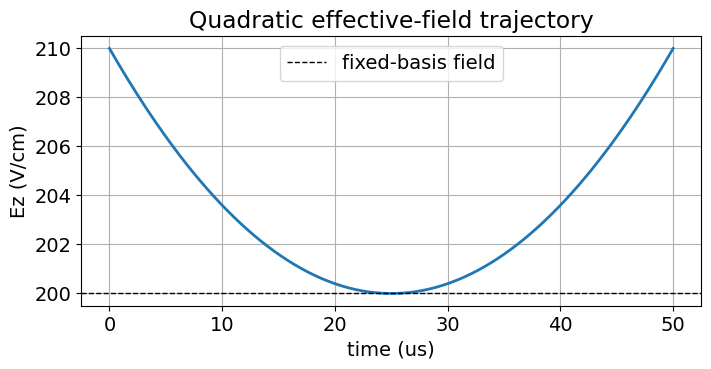

z-span covered in 50.0 us at 184.0 m/s: 9.200 mm


In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t_eval * 1e6, Ez_profile, color="tab:blue", linewidth=2)
ax.axhline(E_static, color="black", linestyle="--", linewidth=1, label="fixed-basis field")
ax.set_xlabel("time (us)")
ax.set_ylabel("Ez (V/cm)")
ax.set_title("Quadratic effective-field trajectory")
ax.legend()
plt.show()

print(
    f"z-span covered in {t_total * 1e6:.1f} us at {velocity:.1f} m/s: {z_profile_mm[-1] - z_profile_mm[0]:.3f} mm"
)

In [4]:
effective_reference_system, _ = build_compact_reference_decomposed_bundle(
    transition=transition,
    optical_polarization=polarization,
    electric_field=(0.0, 0.0, E_static),
    magnetic_field=magnetic_field,
)
rabi_symbol = effective_reference_system.coupling_symbols[0]
detuning_symbol = next(
    symbol
    for symbol in effective_reference_system.H_symbolic.free_symbols
    if str(symbol).startswith("\u03b4") or str(symbol).lower().startswith("delta")
)

effective_model = prepare_lindblad_safe_compact_interpolated_model(
    field_points=field_points,
    transition=transition,
    optical_polarization=polarization,
    magnetic_field=magnetic_field,
    master_field=E_static,
)

effective_ground_indices, rho0_effective = uniform_effective_ground_density(effective_model)
effective_params = LindbladParameters(
    {
        smp.Symbol("Ez"): Ez_expr,
        rabi_symbol: Parameter("omega_rabi", Omega0),
        detuning_symbol: Parameter("delta_ref", detuning_at_200),
    }
)

effective_plan = prepare_effective_lindblad_rust_plan(effective_model, effective_params)
effective_result = solve_effective_lindblad(
    effective_plan,
    rho0_effective,
    (0.0, t_total),
    saveat=t_eval,
    solver="dopri5",
    reltol=1e-7,
    abstol=1e-9,
    dt=1e-10,
    output="full",
)

effective_rho = effective_result.density_matrices()
effective_populations = effective_result.populations()
effective_excited_population = effective_populations[:, effective_model.excited_indices].sum(axis=1)
effective_scattering_rate = np.array(
    [
        np.real(
            np.trace(
                rho
                @ effective_model.effective_bundle((0.0, 0.0, float(field_z))).jump_rate_operator()
            )
        )
        for rho, field_z in zip(effective_rho, Ez_profile)
    ],
    dtype=float,
)

print(f"Effective model states: {effective_model.n_effective_states}")
print(f"Effective trace drift: {np.max(np.abs(effective_populations.sum(axis=1) - 1.0)):.3e}")

Effective model states: 18
Effective trace drift: 1.776e-15


In [ ]:
transition_selectors = couplings.generate_transition_selectors([transition], [[polarization]])
regular_system = lindblad.generate_OBE_system_transitions(
    [transition],
    transition_selectors,
    E=np.array([0.0, 0.0, E_static], dtype=float),
    B=magnetic_field,
    method="matrix",
    qn_compact=True,
)

regular_ground_indices, rho0_regular = uniform_density_from_selector(
    regular_system.QN, ground_selector
)
regular_excited_indices = states.QuantumSelector(electronic=states.ElectronicState.B).get_indices(
    regular_system.QN
)

regular_parameter_values = {str(symbol): 0.0 for symbol in regular_system.H_symbolic.free_symbols}
for symbol in regular_system.coupling_symbols:
    regular_parameter_values[str(symbol)] = Omega0
for group in regular_system.polarization_symbols:
    symbol_group = group if isinstance(group, (list, tuple)) else [group]
    for symbol in symbol_group:
        regular_parameter_values[str(symbol)] = 1.0 if str(symbol).startswith("PZ") else 0.0

regular_prepared = prepare_lindblad_problem(
    regular_system,
    regular_parameter_values,
    backend="rust",
    hamiltonian_representation="decomposed",
)
regular_result = solve_lindblad(
    regular_prepared,
    rho0_regular,
    (0.0, t_total),
    solver="dopri5_fast",
    execution_mode="expanded_sparse",
    saveat=t_eval,
    dt=1e-10,
    reltol=1e-7,
    abstol=1e-9,
    output="full",
)

regular_rho = regular_result.density_matrices()
regular_populations = regular_result.populations()
regular_excited_population = regular_populations[:, regular_excited_indices].sum(axis=1)
regular_jump_rate_operator = build_jump_rate_operator(regular_system.C_array)
regular_scattering_rate = np.array(
    [np.real(np.trace(rho @ regular_jump_rate_operator)) for rho in regular_rho],
    dtype=float,
)
regular_total_photons = cumulative_integral(t_eval, regular_scattering_rate)
regular_ground_labels = [
    state_label(regular_system.QN[int(index)]) for index in regular_ground_indices
]

effective_total_photons = cumulative_integral(t_eval, effective_scattering_rate)

print(f"Regular OBE states: {len(regular_system.QN)}")
print(f"Regular trace drift: {np.max(np.abs(regular_populations.sum(axis=1) - 1.0)):.3e}")

Regular OBE states: 67
Regular trace drift: 8.882e-16


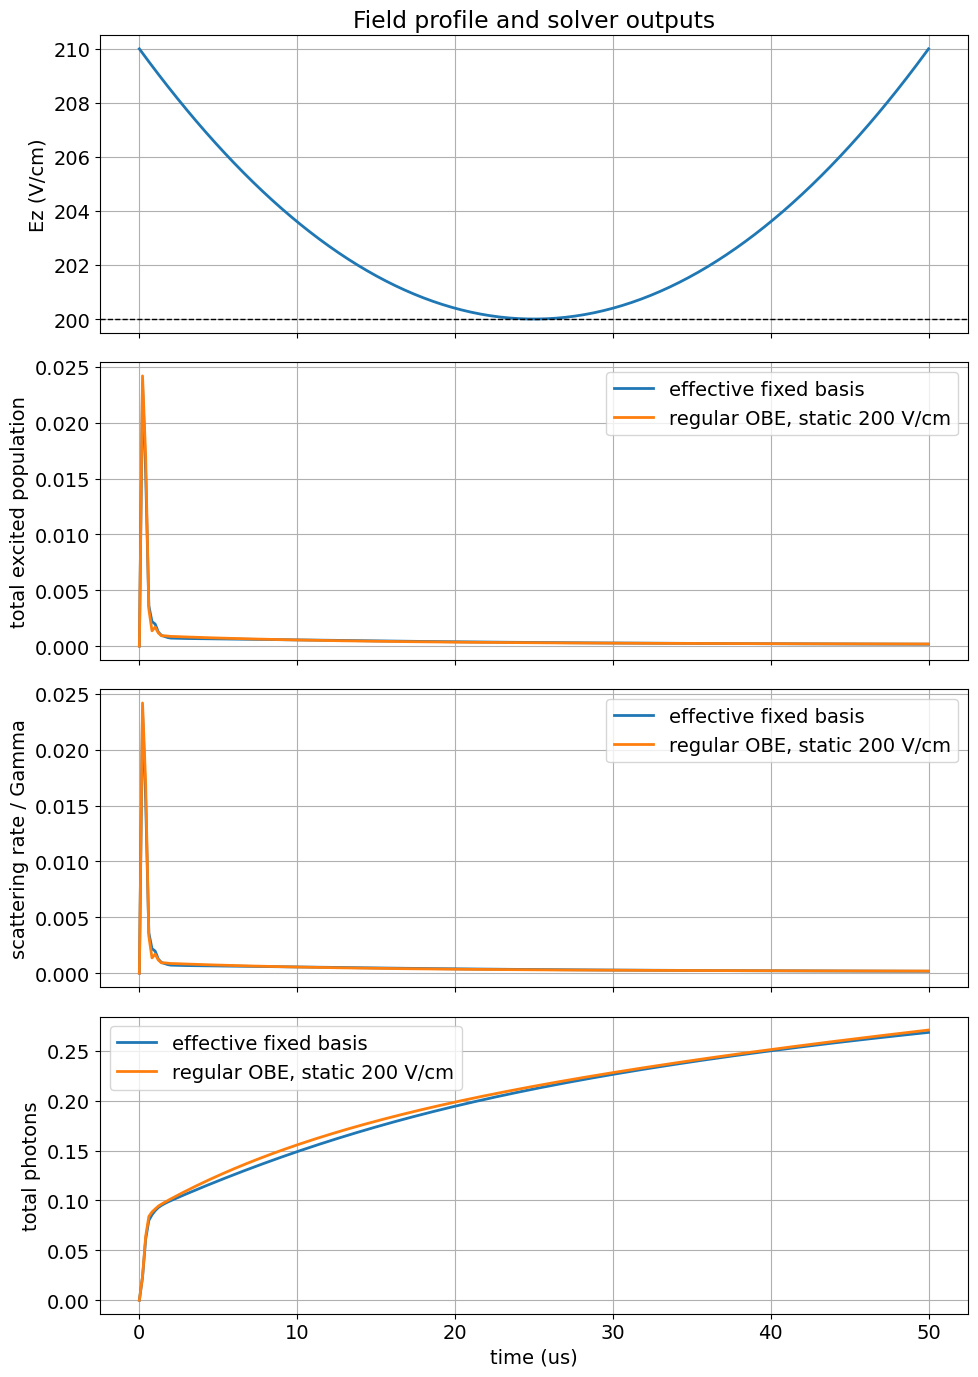

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

axes[0].plot(t_eval * 1e6, Ez_profile, color="tab:blue", linewidth=2)
axes[0].axhline(E_static, color="black", linestyle="--", linewidth=1)
axes[0].set_ylabel("Ez (V/cm)")
axes[0].set_title("Field profile and solver outputs")

axes[1].plot(t_eval * 1e6, effective_excited_population, linewidth=2, label="effective fixed basis")
axes[1].plot(
    t_eval * 1e6, regular_excited_population, linewidth=2, label="regular OBE, static 200 V/cm"
)
axes[1].set_ylabel("total excited population")
axes[1].legend()

axes[2].plot(
    t_eval * 1e6, effective_scattering_rate / Gamma, linewidth=2, label="effective fixed basis"
)
axes[2].plot(
    t_eval * 1e6, regular_scattering_rate / Gamma, linewidth=2, label="regular OBE, static 200 V/cm"
)
axes[2].set_ylabel("scattering rate / Gamma")
axes[2].legend()

axes[3].plot(t_eval * 1e6, effective_total_photons, linewidth=2, label="effective fixed basis")
axes[3].plot(t_eval * 1e6, regular_total_photons, linewidth=2, label="regular OBE, static 200 V/cm")
axes[3].set_xlabel("time (us)")
axes[3].set_ylabel("total photons")
axes[3].legend()

plt.tight_layout()
plt.show()

The effective-model ground-state traces below are plotted in reduced-basis order (`g0`, `g1`, ...). The regular OBE traces keep explicit state labels from the full basis.

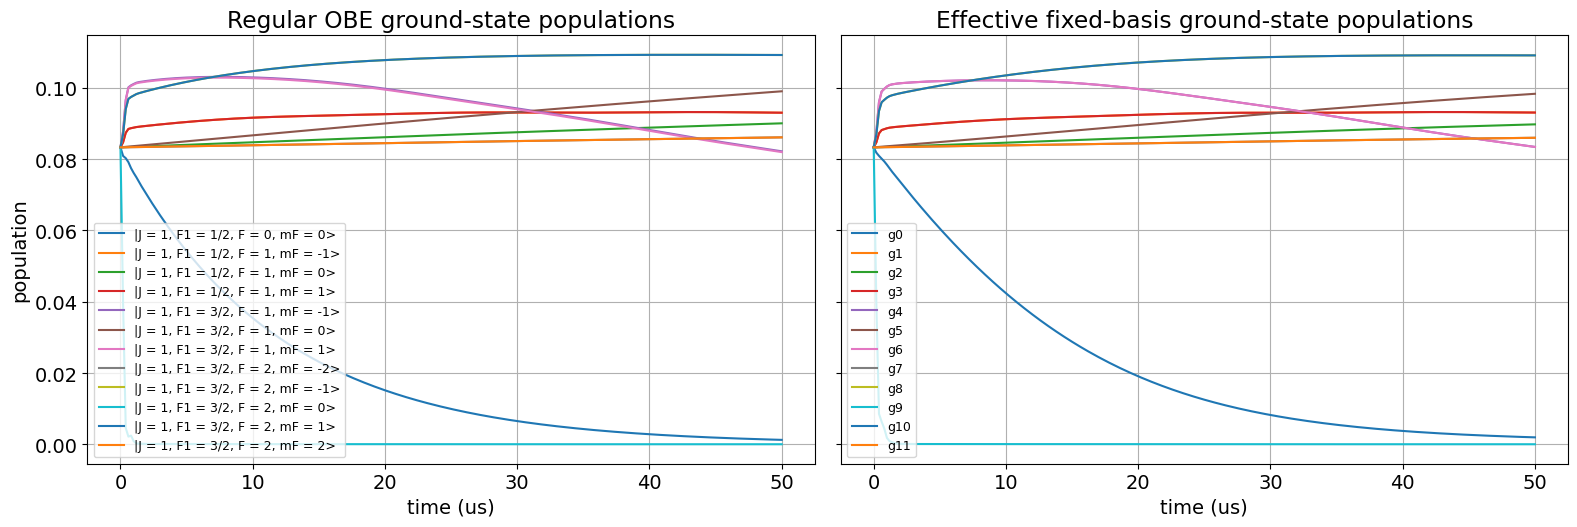

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

for column, label in enumerate(regular_ground_labels):
    axes[0].plot(
        t_eval * 1e6,
        regular_populations[:, regular_ground_indices[column]],
        linewidth=1.5,
        label=label,
    )
axes[0].set_title("Regular OBE ground-state populations")
axes[0].set_xlabel("time (us)")
axes[0].set_ylabel("population")
axes[0].legend(fontsize=9)

for column, state_index in enumerate(effective_ground_indices):
    axes[1].plot(
        t_eval * 1e6, effective_populations[:, state_index], linewidth=1.5, label=f"g{column}"
    )
axes[1].set_title("Effective fixed-basis ground-state populations")
axes[1].set_xlabel("time (us)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
print("Final-state summary")
print(f"  effective final excited population: {effective_excited_population[-1]:.6e}")
print(f"  regular final excited population:   {regular_excited_population[-1]:.6e}")
print(f"  effective final scattering / Gamma: {effective_scattering_rate[-1] / Gamma:.6e}")
print(f"  regular final scattering / Gamma:   {regular_scattering_rate[-1] / Gamma:.6e}")
print(f"  effective total photons:            {effective_total_photons[-1]:.6e}")
print(f"  regular total photons:              {regular_total_photons[-1]:.6e}")

Final-state summary
  effective final excited population: 1.684279e-04
  regular final excited population:   1.878654e-04
  effective final scattering / Gamma: 1.684279e-04
  regular final scattering / Gamma:   1.878654e-04
  effective total photons:            2.684848e-01
  regular total photons:              2.708566e-01
